In [1]:
import os
import matplotlib.pyplot as plt
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette
from autoslo.workload_execution.trace import Trace

In [2]:
pu.RunLocator._check_refresh(force=True)
df = pu.RunLocator.get_runs_df()
df

,run_id,workload_name,num_queries,scale_factor,schema_name,blueprint_name,query_router_name,maxconns,closed_loop
0,1759156767,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_16,RFixed(fixed_cluster_name='cluster_16'),1000,True
1,1759156803,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_32,RFixed(fixed_cluster_name='cluster_32'),1000,True
2,1759156811,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_64,RFixed(fixed_cluster_name='cluster_64'),1000,True
3,1759156817,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_128,RFixed(fixed_cluster_name='cluster_128'),1000,True
4,1759166300,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_256,RFixed(fixed_cluster_name='cluster_256'),1000,True
...,...,...,...,...,...,...,...,...,...
113,1768335454,interference_heavy_compliant,3598,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
114,1768338139,interference_heavy_disruptive,3599,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
115,1768340541,interference_light_compliant,4770,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
116,1768344023,interference_light_disruptive,4765,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False


In [3]:
LIGHT_COMPLIANT_TEMPLATE_IDS = [42,52,55,98]
LIGHT_DISRUPTIVE_TEMPLATE_IDS = [41,8,61]
HEAVY_COMPLIANT_TEMPLATE_IDS = [47,67]
HEAVY_DISRUPTIVE_TEMPLATE_IDS = [64,72,78]
LIGHT_DISRUPTIVE_TEMPLATE_IDS_V2 = [21, 32]


In [15]:
# Plot a scatter plot where the y axis is latency, the x axis is arrival time, and the color is determined by 
# which list the template id belongs to, from the above

def plot_one(ax, workload_name):

    run_id = pu.RunLocator.get_run_ids(workload_name=workload_name)[0]

    trace = Trace(run_id=run_id)
    latencies = trace.latencies_s
    arrival_times = trace.arrival_times()
    tpcds_temp_and_q_idx = trace.tpcds_temp_and_q_idxs

    df = latencies.to_frame(name='latency_s').merge(arrival_times.to_frame(name='arrival_time'), left_index=True, right_index=True)
    df = df.merge(tpcds_temp_and_q_idx.to_frame(name='tpcds_temp_and_q_idx'), left_index=True, right_index=True)
    min_arrival_time = df['arrival_time'].min()
    df['relative_arrival_time'] = (df['arrival_time'] - min_arrival_time).dt.total_seconds()
    df['template_id'] = df['tpcds_temp_and_q_idx'].apply(lambda x: int(x.split('_')[0]))
    df['color'] = df['template_id'].apply(
        lambda tid: Palette.light_green if tid in LIGHT_COMPLIANT_TEMPLATE_IDS else
                    Palette.light_red if tid in LIGHT_DISRUPTIVE_TEMPLATE_IDS_V2 else
                    Palette.dark_green if tid in HEAVY_COMPLIANT_TEMPLATE_IDS else
                    Palette.dark_red if tid in HEAVY_DISRUPTIVE_TEMPLATE_IDS else
                    Palette.GREY
    )
    df['label'] = df['template_id'].apply(
        lambda tid: "Light Compliant" if tid in LIGHT_COMPLIANT_TEMPLATE_IDS else
                    "Light Disruptive" if tid in LIGHT_DISRUPTIVE_TEMPLATE_IDS_V2 else
                    "Heavy Compliant" if tid in HEAVY_COMPLIANT_TEMPLATE_IDS else
                    "Heavy Disruptive" if tid in HEAVY_DISRUPTIVE_TEMPLATE_IDS else
                    "Other"
    )

    # Add some light gray backgroun over the middle ten minutes
    ax.axvspan(600, 1200, color='lightgray', alpha=0.5, zorder=0)

    ax.scatter(df['relative_arrival_time'], df['latency_s'], color=df['color'], label=df['label'], zorder=1)
    ax.set_xlabel("Arrival Time (s)")
    ax.set_ylabel("Latency (s)")
    ax.set_title(f"Interference from {workload_name.replace('_', ' ').title()} Queries")
    # Create a legend with the colors-to-labels mapping
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.light_green, markersize=10, label='Light Compliant'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.light_red, markersize=10, label='Light Disruptive'),    
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.dark_green, markersize=10, label='Heavy Compliant'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.dark_red, markersize=10, label='Heavy Disruptive'), 
    ]

    # Only keep the handles that actualy have points in the plot.
    unique_labels = df['label'].unique()
    handles = [h for h in handles if h.get_label() in unique_labels]


    # Have vertical gridlines be every two minutes
    ax.xaxis.set_major_locator(plt.MultipleLocator(120))

    

    # Flot a dashed line with the p95 latency of the light green queries over
    # each two minute interval
    time_bins = range(0, int(df['relative_arrival_time'].max()) + 120, 120)
    p95_latencies = []
    for i in range(len(time_bins) - 1):
        bin_df = df[(df['relative_arrival_time'] >= time_bins[i]) & (df['relative_arrival_time'] < time_bins[i+1]) & (df['label'] == 'Light Compliant')]
        if not bin_df.empty:
            p95 = bin_df['latency_s'].quantile(0.95)
            p95_latencies.append((time_bins[i] + 60, p95))  # Middle of the bin
    if p95_latencies:
        x_vals, y_vals = zip(*p95_latencies)
        ax.plot(x_vals, y_vals, color=Palette.light_blue, linestyle='--', label='Light Compliant P95 Latency', marker='o', zorder=2)

    # Add a handle for the p95 line for the legend
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.light_blue, linestyle='--', markersize=10, label='Light Compliant P95 Latency'))

    ax.legend(handles=handles)
    ax.set_yscale('log')
    ax.grid(True)

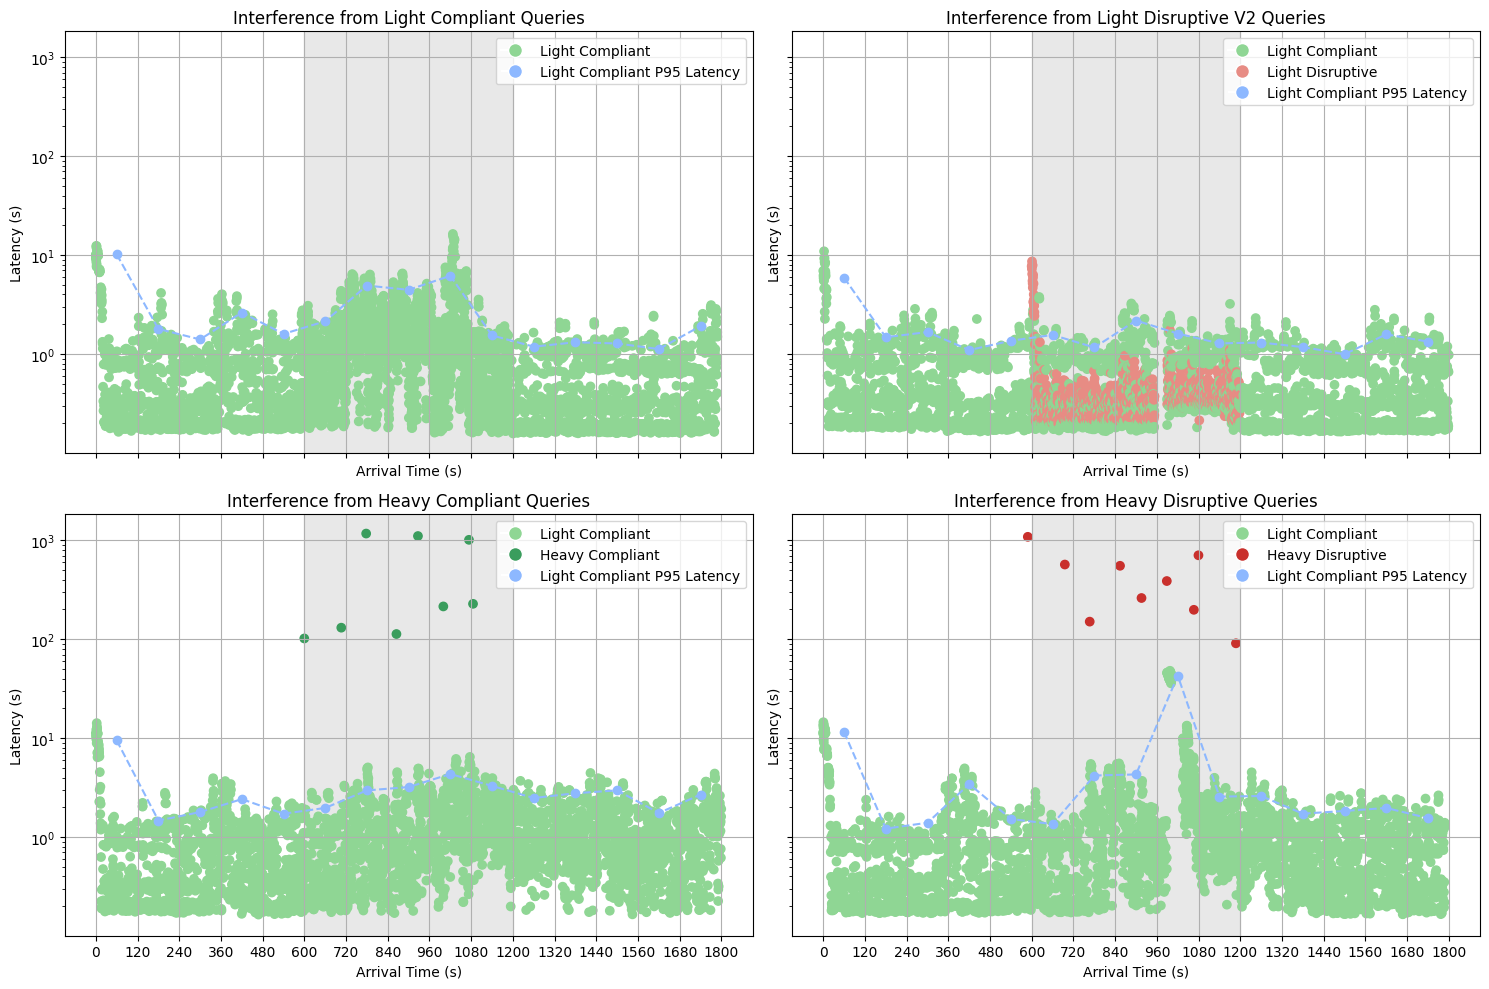

In [16]:
# Plot a 2x2 grid of the four workloads
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
workload_names = ['light_compliant', 'light_disruptive_v2', 'heavy_compliant', 'heavy_disruptive']
for ax, workload_name in zip(axs.flatten(), workload_names):
    plot_one(ax, workload_name)
plt.tight_layout()
plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_large.svg'), bbox_inches='tight')
plt.show()

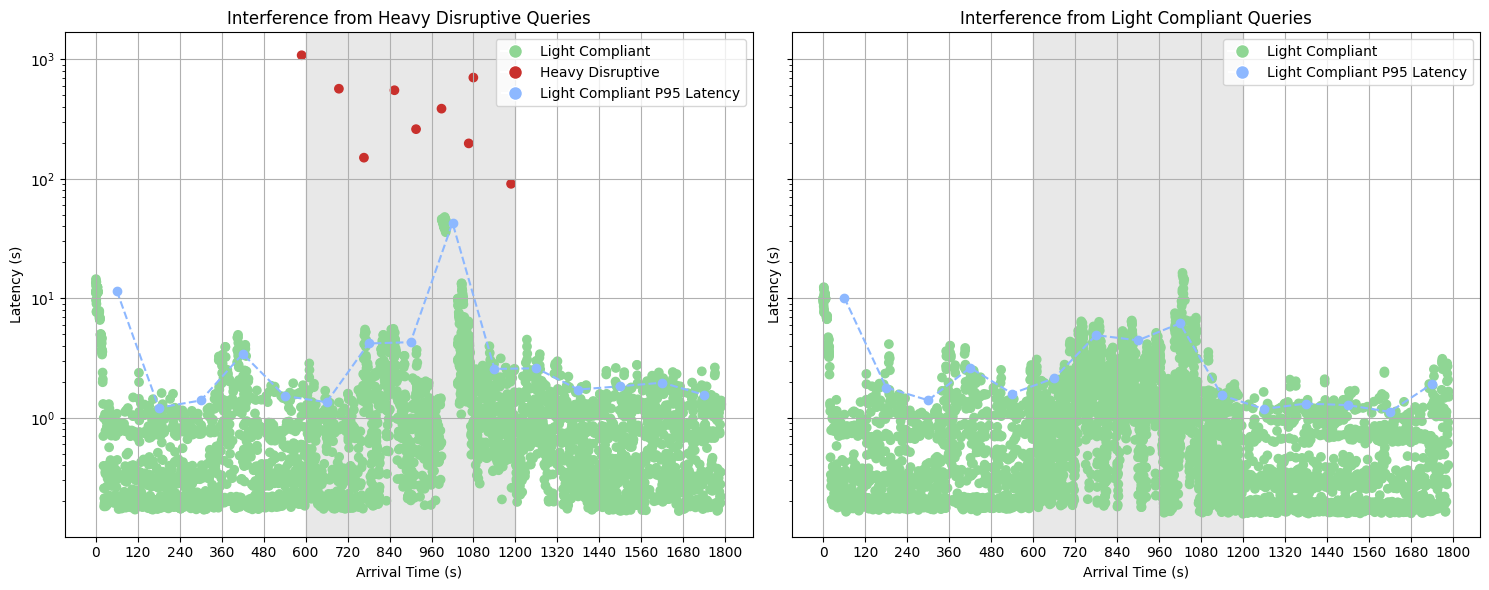

In [18]:
# Plot a 2x2 grid of the four workloads
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
workload_names = ['heavy_disruptive', 'light_compliant']
for ax, workload_name in zip(axs.flatten(), workload_names):
    plot_one(ax, workload_name)
plt.tight_layout()
plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_small.svg'), bbox_inches='tight')
plt.show()